Импорт необходимых модулей:

In [36]:
import imp
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import numpy as np
from PIL import Image 

from cmath import isclose
import math

import multiprocessing
from joblib import Parallel, delayed
# from math import isqrt

import platform
import subprocess

### Генерируем точки + строим графики и изображения

In [37]:
#total_points_sqrt = 3163
total_points_sqrt = 3163
total_points = total_points_sqrt * total_points_sqrt

print(total_points)

10004569


Билдим проект через cmake

In [38]:
if ( os.path.exists('bin/') ):
    subprocess.run(['cmake', '--build', 'bin/', '--target', 'clean'])
subprocess.run(['cmake', '.', '-B', 'bin/', '-G', 'Ninja', '-D', 'CMAKE_BUILD_TYPE=Release'])
subprocess.run(['cmake', '--build', 'bin/'])

[0/2] Re-checking globbed directories...
[1/1] Cleaning all built files...
Cleaning... 17 files.
-- Configuring done
-- Generating done
-- Build files have been written to: /home/joel/Development/practice/nikulin/2_pi_motne_carlo/bin
[0/2] Re-checking globbed directories...
[1/17] Building C object CMakeFiles/pimc_c-CPP_C_PI_MONTE_CARLO.dir/counters.c.o
[2/17] Building C object CMakeFiles/pimc_c-CPP_C_PI_MONTE_CARLO.dir/generators.c.o
[3/17] Building C object CMakeFiles/pimc_cpp-CPP_C_PI_MONTE_CARLO.dir/generators.c.o
[4/17] Linking C static library libpimc_c.a
[5/17] Building C object CMakeFiles/PIMonteCarlo-CPP_C_PI_MONTE_CARLO-C.dir/main.c.o
[6/17] Linking C executable PIMonteCarlo-C
[7/17] Building CXX object CMakeFiles/pimc_cpp-CPP_C_PI_MONTE_CARLO.dir/samples.cpp.o
[8/17] Building CXX object CMakeFiles/pimc_cpp-test-CPP_C_PI_MONTE_CARLO.dir/true_pi_selector_class_test.cpp.o
[9/17] Building CXX object CMakeFiles/pimc_cpp-CPP_C_PI_MONTE_CARLO.dir/true_pi_selector_class.cpp.o
[10/17

CompletedProcess(args=['cmake', '--build', 'bin/'], returncode=0)

Запускаем генерацию точек

In [39]:
if platform.system() == 'Windows':
    out = subprocess.check_output( ".\\bin\\PIMonteCarlo-CPP.exe --xs64 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( ".\\bin\\PIMonteCarlo-CPP.exe --xs1024 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( ".\\bin\\PIMonteCarlo-CPP.exe --mt19937 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( ".\\bin\\PIMonteCarlo-CPP.exe --rand " + str(total_points), shell=True, text=True )
    print(out)
else:
    out = subprocess.check_output( "./bin/PIMonteCarlo-CPP --xs64 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/PIMonteCarlo-CPP --xs1024 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/PIMonteCarlo-CPP --mt19937 " + str(total_points), shell=True, text=True )
    print(out)

    out = subprocess.check_output( "./bin/PIMonteCarlo-CPP --rand " + str(total_points), shell=True, text=True )
    print(out)

Elapsed time for generator: "xs64"; Total values: 10004569	 --- 3568163 microseconds

Elapsed time for generator: "xs1024"; Total values: 10004569	 --- 3494664 microseconds

Elapsed time for generator: "mt19937"; Total values: 10004569	 --- 3508014 microseconds

Elapsed time for generator: "rand"; Total values: 10004569	 --- 3467552 microseconds



Подгружаем сгенерированные выборки:

In [40]:
x64      = pd.read_csv("xs64.csv")
x1024    = pd.read_csv("xs1024.csv")
mt19937  = pd.read_csv("mt19937.csv")
rand     = pd.read_csv("rand.csv")

Вывод первых 5-ти значий со сгенерированного файла:

In [41]:
x64.head()

,randoms
0,0.988629
1,0.615396
2,0.757645
3,0.885374
4,0.065438


Описательная статистика:

In [42]:
x64['randoms'].describe()

count    1.000457e+07
mean     5.000250e-01
std      2.886749e-01
min      1.430760e-07
25%      2.499600e-01
50%      5.000700e-01
75%      7.500030e-01
max      1.000000e+00
Name: randoms, dtype: float64

Строим гистограммы:

In [43]:
bins = 1000
bins_ranges = np.arange(start=0, stop=1, step=1 / bins)

In [44]:
hist_x64, bins_ranges = np.histogram(x64.to_numpy(), bins_ranges)
hist_x1024, bins_ranges = np.histogram(x1024.to_numpy(), bins_ranges)
hist_mt19937, bins_ranges = np.histogram(mt19937.to_numpy(), bins_ranges)
hist_rand, bins_ranges = np.histogram(rand.to_numpy(), bins_ranges)

(9690.0, 10352.0)

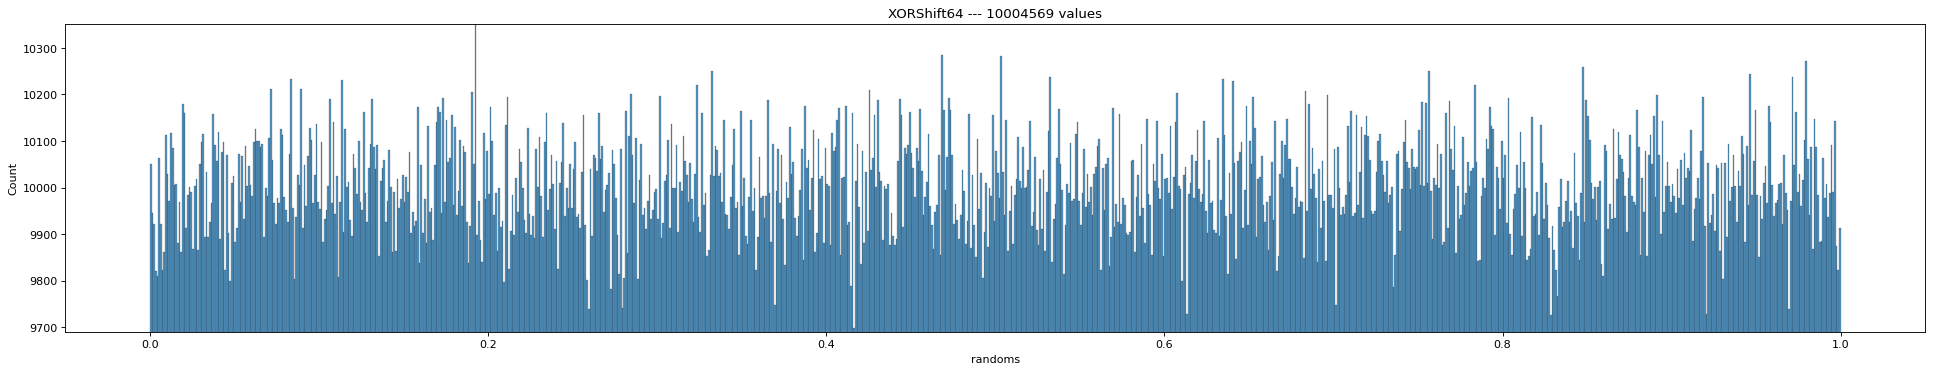

In [45]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x64, x="randoms", bins=bins).set(title='XORShift64 --- ' + str(total_points) + ' values')

plt.ylim(bottom=np.min(hist_x64), top=np.max(hist_x64))

In [46]:
data = 255 * np.array(x64)
data = np.uint8(data)

In [47]:
data.shape

(10004569, 1)

In [48]:
data = data.reshape(total_points_sqrt, total_points_sqrt)
print(data)

[[252 156 193 ... 127 222 197]
 [ 53 234 104 ...  77 202 125]
 [ 98 108 176 ... 128 104 164]
 ...
 [155 232 236 ...  15 221  89]
 [242 226 203 ...  70 249  78]
 [ 97 215 196 ...  21 112 151]]


In [49]:
data.shape

(3163, 3163)

In [50]:
img = Image.fromarray(data, 'L')
img.save('XORShift64_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9697.0, 10313.0)

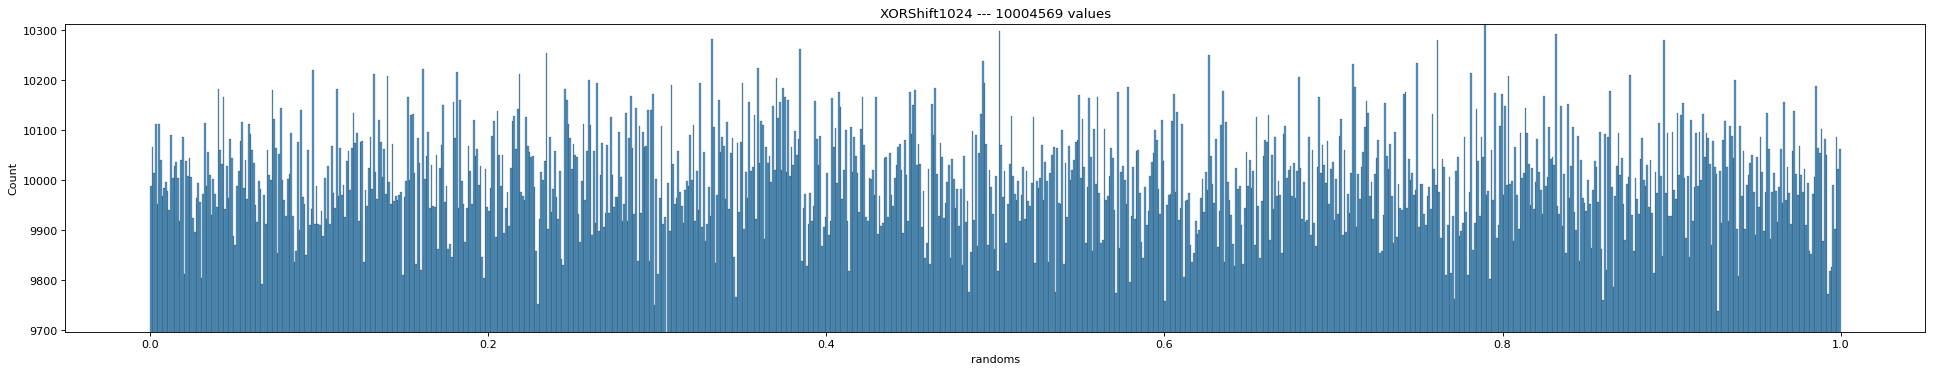

In [51]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x1024, x="randoms", bins=bins).set(title='XORShift1024 --- ' + str(total_points) + ' values')

plt.ylim(bottom=np.min(hist_x1024), top=np.max(hist_x1024))

In [52]:
data = 255 * np.array(x1024)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [53]:
img = Image.fromarray(data, 'L')
img.save('XORShift1024_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9714.0, 10302.0)

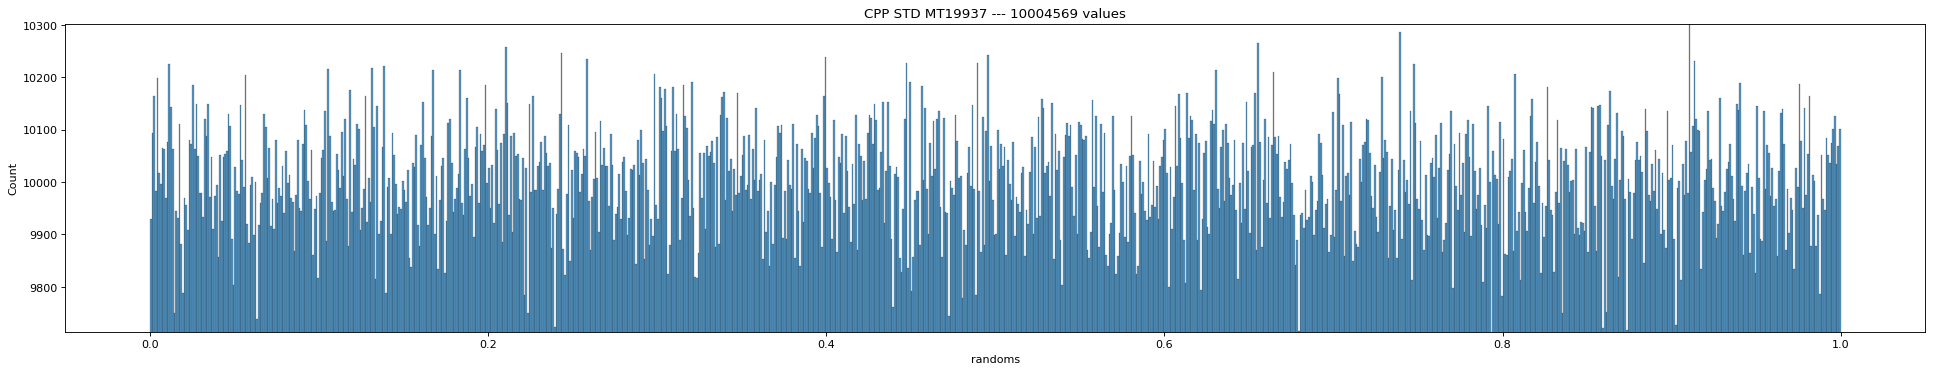

In [54]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=mt19937, x="randoms", bins=bins).set(title='CPP STD MT19937 --- ' + str(total_points) + ' values')

plt.ylim(bottom=np.min(hist_mt19937), top=np.max(hist_mt19937))

In [55]:
data = 255 * np.array(mt19937)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [56]:
img = Image.fromarray(data, 'L')
img.save('MT19937_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9679.0, 10339.0)

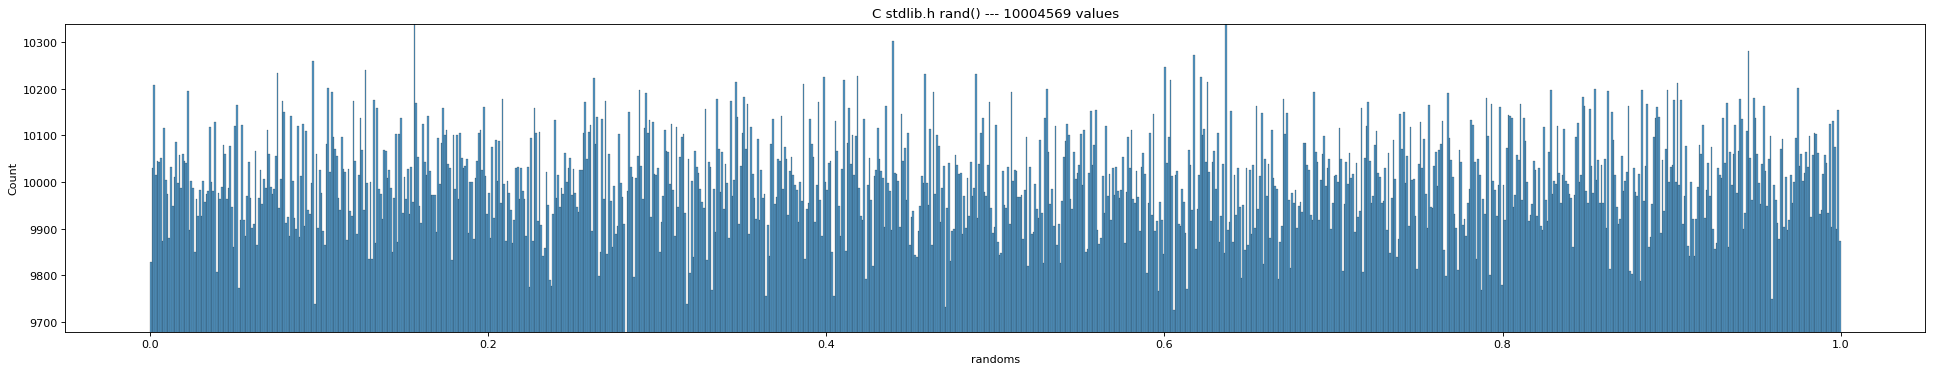

In [57]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=rand, x="randoms", bins=bins).set(title='C stdlib.h rand() --- ' + str(total_points) + ' values')

plt.ylim(bottom=np.min(hist_rand), top=np.max(hist_rand))

In [58]:
data = 255 * np.array(rand)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [59]:
img = Image.fromarray(data, 'L')
img.save('CSTDLibRand_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

## Метрики качества

In [60]:
# метод проверки, что хотя бы одно сгенерированное число из выборки есть в диапазоне [left..right), 
# ИДЕАЛЬНЫЙ ГЕНЕРАТОР выдаст ОДНО ЧИСЛО на ОДИН ДИАПАЗОН
def parallel_task(left, step, generated_values):
    right = left + step # next элемент (правый сосед, как граница диапазона) из массива expected_values

    for generated in generated_values:
        if (isclose(generated, left) or generated > left) and generated < right:
            # если сгенерированное число (generated) >= левой границе диапазона (left) и строго меньше правой границы (right) ---> выдать единицу
            return 1
                    
    return 0

# метод проверки качества сгенерированных значений, два типа проверки 'by-sum' -- быстрее и 'by-element' -- медленнее (но точнее)
def get_quality_of_values(generated_values, type='by-sum'):
    size = len(generated_values)

    # массив ожидаемых значений [0..1)
    range_step = 1.0 / size
    expected_values = np.arange(start=0, stop=1, step=range_step)    # ожидаемые значения ИДЕАЛЬНОГО ГЕНЕРАТОРА [0, 0.001, 0.002, ..., 1)

    generated_values = generated_values.to_numpy()
    error = None

    print(f'Expected values: {expected_values}')
    print(f'Generated values: {generated_values}')

    # проверка схожести суммы идеальных значений с суммой реальных значений
    # по сумме
    if type == 'by-sum':

        ideal_sum = expected_values.sum()
        real_sum = generated_values.sum()

        # отклонение от необходимой суммы в процентах
        error = abs( ideal_sum - real_sum ) 
        error /= ideal_sum

    # по элементно
    elif type == 'by-element':

        # parallel loop
        num_cores = multiprocessing.cpu_count()
        results = Parallel(n_jobs=num_cores)(delayed(parallel_task)(ideal, range_step, generated_values) for ideal in expected_values)

        # реальное количество диапазонов, в которых есть сгенерированные числа (В ИДЕАЛЕ, это число будет равно КОЛИЧЕСТВУ СГЕНЕРИРОВАННЫХ ЧИСЕЛ)
        good_elements = np.array(results).sum()

        error = 1 - good_elements / size
        print(f'Good elements: {good_elements}')
        print(f'Total generated values: {size}\nError: {error}')

    else:
        raise ValueError("Wrong type!")

    return 1 - error    # вывод качества с учётом ошибки ---> 1 - идеальный генератор, 0 - плохой генератор

Параметры для проверки качества:

In [61]:
#type = 'by-element'
type = 'by-sum'

Метрика качества для XorShift64:

In [62]:
quality = get_quality_of_values(x64, type)
print(f'XorShift64 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.988629 ]
 [0.615396 ]
 [0.757645 ]
 ...
 [0.0857383]
 [0.440206 ]
 [0.593293 ]]
XorShift64 Quality: 0.9999499641815406


Метрика качества для XorShift1024:

In [63]:
quality = get_quality_of_values(x1024, type)
print(f'XorShift1024 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.719755 ]
 [0.178686 ]
 [0.406345 ]
 ...
 [0.0649613]
 [0.172804 ]
 [0.398273 ]]
XorShift1024 Quality: 0.999825286691234


Метрика качества для MT19937:

In [64]:
quality = get_quality_of_values(mt19937, type)
print(f'MT19937 Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.483447]
 [0.574515]
 [0.504659]
 ...
 [0.275426]
 [0.106949]
 [0.285178]]
MT19937 Quality: 0.999758314880025


In [65]:
quality = get_quality_of_values(rand, type)
print(f'C stdlib.h rand() Quality: {quality}')

Expected values: [0.00000000e+00 9.99543309e-08 1.99908662e-07 ... 9.99999700e-01
 9.99999800e-01 9.99999900e-01]
Generated values: [[0.355018]
 [0.94312 ]
 [0.368049]
 ...
 [0.2046  ]
 [0.835225]
 [0.358558]]
C stdlib.h rand() Quality: 0.9998586315025054


### Среднеквадратичное отклонение

In [66]:
size = len(hist_x64)
avg = np.mean(hist_x64)
max = np.max(hist_x64)
min = np.min(hist_x64)

# print(len(bins))
# print(avg)
# print(size)

RMSD = 0
for h in hist_x64:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for XorShift64 = {NRMSD}')

Root mean square deviation for XorShift64 = 0.15178483841029367


In [67]:
size = len(hist_x1024)
avg = np.mean(hist_x1024)
max = np.max(hist_x1024)
min = np.min(hist_x1024)

RMSD = 0
for h in hist_x1024:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for XorShift1024 = {NRMSD}')

Root mean square deviation for XorShift1024 = 0.1601396545123342


In [68]:
size = len(hist_mt19937)
avg = np.mean(hist_mt19937)
max = np.max(hist_mt19937)
min = np.min(hist_mt19937)

RMSD = 0
for h in hist_mt19937:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for MT19937 = {NRMSD}')

Root mean square deviation for MT19937 = 0.1710245358372783


In [69]:
size = len(hist_rand)
avg = np.mean(hist_rand)
max = np.max(hist_rand)
min = np.min(hist_rand)

RMSD = 0
for h in hist_rand:
    RMSD += ((avg - h) ** 2) / size
RMSD = math.sqrt(RMSD)

NRMSD = RMSD / (max - min)
print(f'Root mean square deviation for rand() = {NRMSD}')

Root mean square deviation for rand() = 0.15497179006968115
